# Import Required Libraries

In [1]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose,
    Dropout,
    Concatenate
)

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

print("TensorFlow Version :", tf.__version__)
print("Num GPUs Available :", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version : 2.21.0
Num GPUs Available : 0


 # Path

In [28]:


import os

# Base Dataset Folder
BASE_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET"

# Preprocessed Dataset
DATASET_PATH = os.path.join(BASE_PATH, "Preprocessed_segmented")

# Train
TRAIN_IMAGE_DIR = os.path.join(DATASET_PATH, "train", "images")
TRAIN_MASK_DIR  = os.path.join(DATASET_PATH, "train", "masks")

# Test
TEST_IMAGE_DIR = os.path.join(DATASET_PATH, "test", "images")
TEST_MASK_DIR  = os.path.join(DATASET_PATH, "test", "masks")

# Hyperparameters
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 1

BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-4

print("=" * 60)
print("Training Images :", TRAIN_IMAGE_DIR)
print("Training Masks  :", TRAIN_MASK_DIR)
print("Testing Images  :", TEST_IMAGE_DIR)
print("Testing Masks   :", TEST_MASK_DIR)
print("=" * 60)

Training Images : C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\images
Training Masks  : C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\masks
Testing Images  : C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\test\images
Testing Masks   : C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\test\masks


In [29]:
# ============================================================
# Cell 3: Verify Dataset Structure
# ============================================================

train_images = sorted(os.listdir(TRAIN_IMAGE_DIR))
train_masks = sorted(os.listdir(TRAIN_MASK_DIR))

test_images = sorted(os.listdir(TEST_IMAGE_DIR))
test_masks = sorted(os.listdir(TEST_MASK_DIR))

print(f"Training Images : {len(train_images)}")
print(f"Training Masks  : {len(train_masks)}")

print(f"Testing Images  : {len(test_images)}")
print(f"Testing Masks   : {len(test_masks)}")

assert len(train_images) == len(train_masks), "Train image-mask count mismatch!"
assert len(test_images) == len(test_masks), "Test image-mask count mismatch!"

print("\n✅ Dataset Verified Successfully")

Training Images : 3933
Training Masks  : 3933
Testing Images  : 860
Testing Masks   : 860

✅ Dataset Verified Successfully


# Train and Validation Split

In [30]:
# ============================================================
# Cell 4: Create Train & Validation Split
# ============================================================

from glob import glob
from sklearn.model_selection import train_test_split

# Load image and mask paths
train_image_paths = sorted(glob(os.path.join(TRAIN_IMAGE_DIR, "*")))
train_mask_paths  = sorted(glob(os.path.join(TRAIN_MASK_DIR, "*")))

test_image_paths = sorted(glob(os.path.join(TEST_IMAGE_DIR, "*")))
test_mask_paths  = sorted(glob(os.path.join(TEST_MASK_DIR, "*")))

# Split training data into Train (80%) and Validation (20%)
(
    train_image_paths,
    val_image_paths,
    train_mask_paths,
    val_mask_paths
) = train_test_split(
    train_image_paths,
    train_mask_paths,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("=" * 60)
print("Training Images   :", len(train_image_paths))
print("Validation Images :", len(val_image_paths))
print("Testing Images    :", len(test_image_paths))
print("=" * 60)

Training Images   : 3146
Validation Images : 787
Testing Images    : 860


# Images and masks loading function 

In [31]:
# ============================================================
# Cell 5: Image & Mask Loading Function
# ============================================================

def load_image_mask(image_path, mask_path):
    """
    Reads an MRI image and its corresponding segmentation mask.
    """

    # Read grayscale MRI image
    image = cv2.imread(image_path.decode(), cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))

    # Normalize image
    image = image.astype(np.float32) / 255.0

    # Add channel dimension
    image = np.expand_dims(image, axis=-1)

    # Read grayscale mask
    mask = cv2.imread(mask_path.decode(), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))

    # Convert mask into binary
    mask = (mask > 127).astype(np.float32)

    # Add channel dimension
    mask = np.expand_dims(mask, axis=-1)

    return image, mask

# Tensroflow  wrapper

In [32]:
# ============================================================
# Cell 6: TensorFlow Wrapper
# ============================================================

def tf_parse(image_path, mask_path):

    image, mask = tf.numpy_function(
        load_image_mask,
        [image_path, mask_path],
        [tf.float32, tf.float32]
    )

    image.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])
    mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])

    return image, mask

# Cretea tf.dataset

In [33]:
# ============================================================
# Cell 7: Create TensorFlow Dataset
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


def create_dataset(image_paths, mask_paths, batch_size):

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))

    dataset = dataset.map(tf_parse, num_parallel_calls=AUTOTUNE)

    dataset = dataset.batch(batch_size)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_dataset = create_dataset(
    train_image_paths,
    train_mask_paths,
    BATCH_SIZE
)

val_dataset = create_dataset(
    val_image_paths,
    val_mask_paths,
    BATCH_SIZE
)

test_dataset = create_dataset(
    test_image_paths,
    test_mask_paths,
    BATCH_SIZE
)

print("Datasets Created Successfully")

Datasets Created Successfully


# Visualize Training Sample

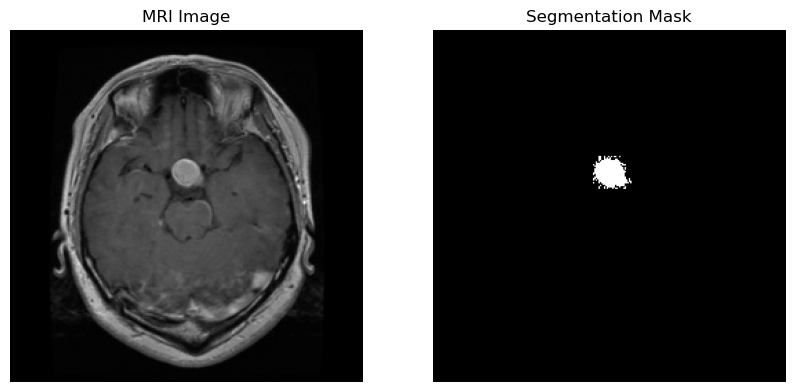

In [34]:
# ============================================================
# Cell 8: Visualize Sample Image & Mask
# ============================================================

sample_image, sample_mask = next(iter(train_dataset))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(sample_image[0], cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sample_mask[0], cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

# dice Coefficient

In [35]:
# ============================================================
# Cell 9 : Dice Coefficient
# ============================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) +
        smooth
    )

# Dice Loss

In [36]:
# ============================================================
# Cell 10 : Dice Loss
# ============================================================

def dice_loss(y_true, y_pred):

    return 1.0 - dice_coefficient(y_true, y_pred)

# BCE + dice loss

In [37]:
# ============================================================
# Cell 11 : Binary Cross Entropy + Dice Loss
# ============================================================

bce = tf.keras.losses.BinaryCrossentropy()

def total_loss(y_true, y_pred):

    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

# IOU metric

In [38]:
# ============================================================
# Cell 12 : IoU Metric
# ============================================================

def iou_score(y_true, y_pred, smooth=1e-6):

    y_true = tf.keras.backend.flatten(y_true)

    y_pred = tf.keras.backend.flatten(y_pred)

    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)

    union = (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) -
        intersection
    )

    return (intersection + smooth) / (union + smooth)

# Convolution Block

In [39]:
# ============================================================
# Cell 13 : Convolution Block
# ============================================================

from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation

def conv_block(inputs, filters):

    x = Conv2D(
        filters,
        3,
        padding="same"
    )(inputs)

    x = BatchNormalization()(x)

    x = Activation("relu")(x)

    x = Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = BatchNormalization()(x)

    x = Activation("relu")(x)

    return x

# Encoded Block

In [40]:
# ============================================================
# Cell 14 : Encoder Block
# ============================================================

def encoder_block(inputs, filters):

    x = conv_block(inputs, filters)

    p = MaxPooling2D((2,2))(x)

    p = Dropout(0.3)(p)

    return x, p

# Decoder Block 

In [41]:
# ============================================================
# Cell 15 : Decoder Block
# ============================================================

def decoder_block(inputs, skip_features, filters):

    x = Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)

    x = Concatenate()([x, skip_features])

    x = Dropout(0.3)(x)

    x = conv_block(x, filters)

    return x

# Buidl U-Net Architecture

In [42]:
# ============================================================
# Cell 16 : Build U-Net Architecture
# ============================================================

def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)):

    inputs = Input(input_shape)

    # ================= Encoder =================

    s1, p1 = encoder_block(inputs, 64)

    s2, p2 = encoder_block(p1, 128)

    s3, p3 = encoder_block(p2, 256)

    s4, p4 = encoder_block(p3, 512)

    # ================= Bottleneck =================

    b1 = conv_block(p4, 1024)

    # ================= Decoder =================

    d1 = decoder_block(b1, s4, 512)

    d2 = decoder_block(d1, s3, 256)

    d3 = decoder_block(d2, s2, 128)

    d4 = decoder_block(d3, s1, 64)

    # ================= Output =================

    outputs = Conv2D(
        1,
        kernel_size=1,
        activation="sigmoid",
        padding="same"
    )(d4)

    model = Model(inputs, outputs, name="U_Net")

    return model

# Create Model 

In [43]:
# ============================================================
# Cell 17 : Create U-Net Model
# ============================================================

model = build_unet()

print("U-Net Model Created Successfully")

U-Net Model Created Successfully


# compile Model 

In [44]:
# ============================================================
# Cell 18 : Compile Model
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE
)

model.compile(
    optimizer=optimizer,
    loss=total_loss,
    metrics=[
        dice_coefficient,
        iou_score,
        "binary_accuracy"
    ]
)

print("Model Compiled Successfully")

Model Compiled Successfully


# Mdoel summary 

In [45]:
# ============================================================
# Cell 19 : Model Summary
# ============================================================

model.summary()

Model: "U_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 256, 256, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_19 (Conv2D)            │ (None, 256, 256, 64)      │             640 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_18        │ (None, 256, 256, 64)      │             256 │ conv2d_19[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_18 (Activation)    │ (None, 256, 256, 64)      │               0 │ batch_normalization_18[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_20 (Conv2D)            │ (None, 256, 256, 64)      │          36,928 │ activation_18[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_19        │ (None, 256, 256, 64)      │             256 │ conv2d_20[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_19 (Activation)    │ (None, 256, 256, 64)      │               0 │ batch_normalization_19[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 128, 128, 64)      │               0 │ activation_19[0][0]        │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_8 (Dropout)           │ (None, 128, 128, 64)      │               0 │ max_pooling2d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_21 (Conv2D)            │ (None, 128, 128, 128)     │          73,856 │ dropout_8[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_20        │ (None, 128, 128, 128)     │             512 │ conv2d_21[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_20 (Activation)    │ (None, 128, 128, 128)     │               0 │ batch_normalization_20[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_22 (Conv2D)            │ (None, 128, 128, 128)     │         147,584 │ activation_20[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_21        │ (None, 128, 128, 128)     │             512 │ conv2d_22[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_21 (Activation)    │ (None, 128, 128, 128)     │               

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

# Training Callbacks

In [46]:
# ============================================================
# Cell 20 : Training Callbacks
# ============================================================

checkpoint = ModelCheckpoint(
    "best_unet.keras",
    monitor="val_dice_coefficient",
    mode="max",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    earlystop,
    reduce_lr
]

print("Callbacks Ready")

Callbacks Ready


# Train U-Net

In [ ]:
# ============================================================
# Cell 21 : Train U-Net
# ============================================================

history = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/50
  6/394 ━━━━━━━━━━━━━━━━━━━━ 3:17:15 31s/step - binary_accuracy: 0.4911 - dice_coefficient: 0.0503 - iou_score: 0.0300 - loss: 1.7059

In [1]:
print(dice_loss)

NameError: name 'dice_loss' is not defined

# Save Final Model 

In [ ]:
# ============================================================
# Cell 22 : Save Final Model
# ============================================================

model.save("final_unet.keras")

print("Final model saved successfully.")

# Plot Training Curves

In [ ]:
# ============================================================
# Cell 23 : Plot Training Curves
# ============================================================

plt.figure(figsize=(16,5))

# Loss
plt.subplot(1,3,1)

plt.plot(history.history["loss"], label="Train Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss")

plt.legend()

# Dice

plt.subplot(1,3,2)

plt.plot(history.history["dice_coefficient"], label="Train Dice")

plt.plot(history.history["val_dice_coefficient"], label="Validation Dice")

plt.title("Dice Coefficient")

plt.legend()

# IoU

plt.subplot(1,3,3)

plt.plot(history.history["iou_score"], label="Train IoU")

plt.plot(history.history["val_iou_score"], label="Validation IoU")

plt.title("IoU Score")

plt.legend()

plt.tight_layout()

plt.show()

# Evaluate on test dataset

In [ ]:
# ============================================================
# Cell 24 : Evaluate U-Net
# ============================================================

results = model.evaluate(test_dataset, verbose=1)

print("\n========== Test Results ==========")

print(f"Loss             : {results[0]:.4f}")

print(f"Dice Coefficient : {results[1]:.4f}")

print(f"IoU Score        : {results[2]:.4f}")

print(f"Binary Accuracy  : {results[3]:.4f}")

# Visualize prediction

In [ ]:
# ============================================================
# Cell 25 : Visualize Predictions
# ============================================================

images, masks = next(iter(test_dataset))

predictions = model.predict(images)

predictions = (predictions > 0.5).astype(np.float32)

plt.figure(figsize=(15,12))

for i in range(3):

    plt.subplot(3,3,3*i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title("MRI")

    plt.axis("off")


    plt.subplot(3,3,3*i+2)

    plt.imshow(masks[i].squeeze(), cmap="gray")

    plt.title("Ground Truth")

    plt.axis("off")


    plt.subplot(3,3,3*i+3)

    plt.imshow(predictions[i].squeeze(), cmap="gray")

    plt.title("Prediction")

    plt.axis("off")

plt.tight_layout()

plt.show()

# Save training history

In [ ]:
# ============================================================
# Cell 26 : Save Training History
# ============================================================

import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv("training_history.csv", index=False)

print("Training history saved.")

Loaded model from: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras


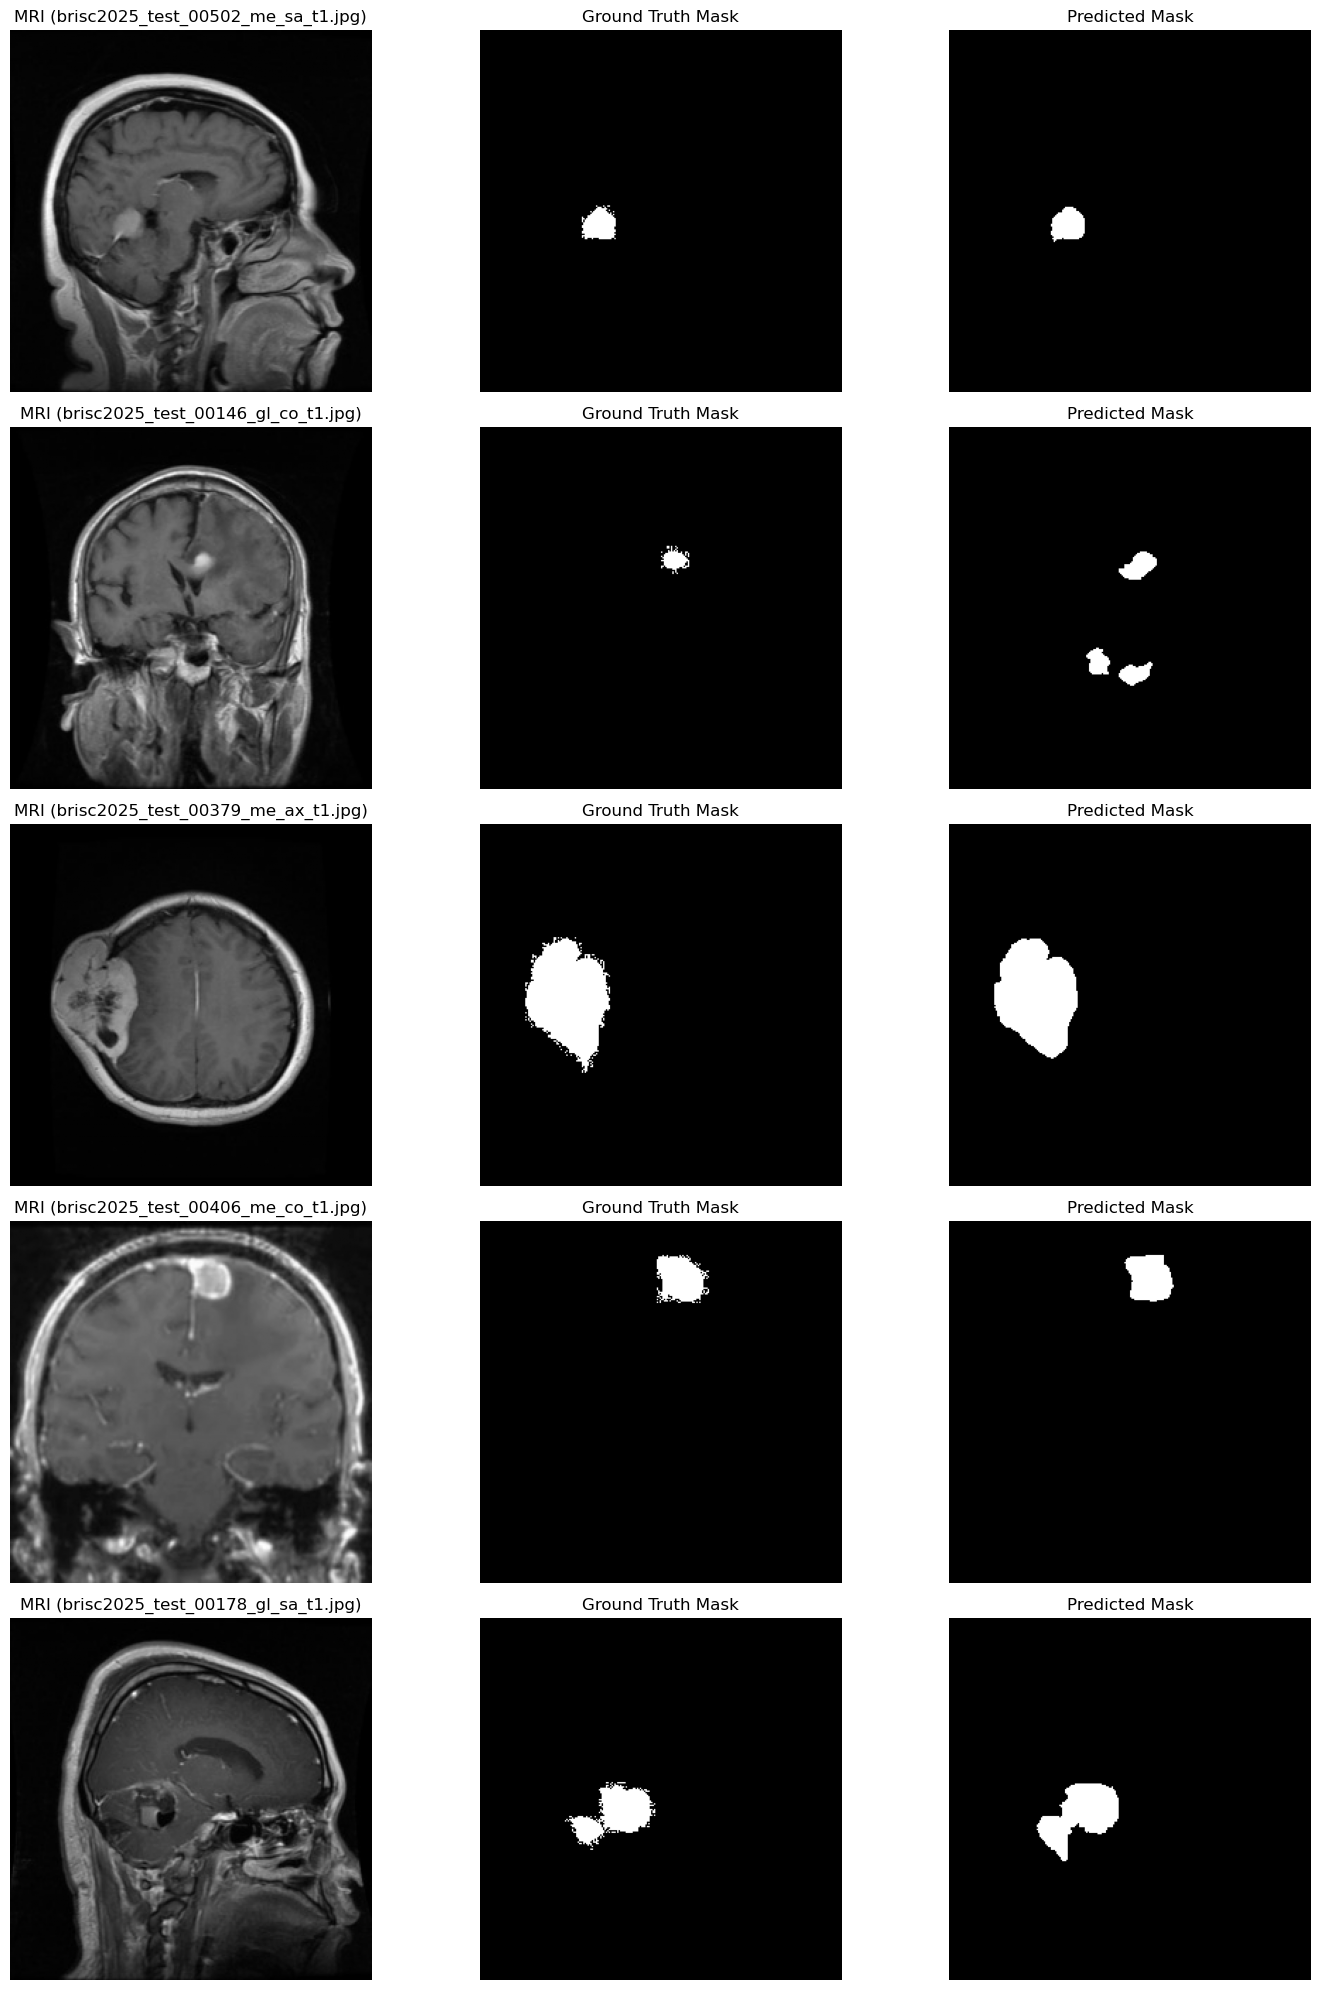

Saved to: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Images\prediction_results.png


In [2]:
# ============================================================
# Random Test Sample Comparison: Image vs Ground Truth vs Prediction
# (Standalone — paths set below)
# ============================================================

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ---------------- Config ----------------
MODEL_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras"
# or use final_unet.keras instead:
# MODEL_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\final_unet.keras"

TEST_IMAGE_DIR = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\test\images"
TEST_MASK_DIR  = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\test\masks"

IMG_HEIGHT = 256
IMG_WIDTH = 256

# ---------------- Redefine custom loss/metric functions ----------------
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()

def total_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

# ---------------- Load model ----------------
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "total_loss": total_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score,
        "dice_loss": dice_loss
    }
)

print(f"Loaded model from: {MODEL_PATH}")

# ---------------- Pick 5 random test samples ----------------
test_image_paths = sorted(
    os.path.join(TEST_IMAGE_DIR, f) for f in os.listdir(TEST_IMAGE_DIR)
)
test_mask_paths = sorted(
    os.path.join(TEST_MASK_DIR, f) for f in os.listdir(TEST_MASK_DIR)
)

assert len(test_image_paths) == len(test_mask_paths), "Image/Mask count mismatch!"

random_indices = random.sample(range(len(test_image_paths)), 5)

# ---------------- Predict and plot ----------------
plt.figure(figsize=(15, 20))

for i, idx in enumerate(random_indices):

    img_path = test_image_paths[idx]
    mask_path = test_mask_paths[idx]

    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))
    image_norm = image.astype(np.float32) / 255.0
    image_input = np.expand_dims(image_norm, axis=(0, -1))

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    mask_binary = (mask > 127).astype(np.float32)

    pred = model.predict(image_input, verbose=0)
    pred_mask = (pred[0, :, :, 0] > 0.5).astype(np.float32)

    plt.subplot(5, 3, 3*i + 1)
    plt.imshow(image_norm, cmap="gray")
    plt.title(f"MRI ({os.path.basename(img_path)})")
    plt.axis("off")

    plt.subplot(5, 3, 3*i + 2)
    plt.imshow(mask_binary, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(5, 3, 3*i + 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")
target_path=r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\Images"
save_path = os.path.join(target_path, "prediction_results.png")
plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved to:", save_path)

# Testing Random image from path 

Loaded model from: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras


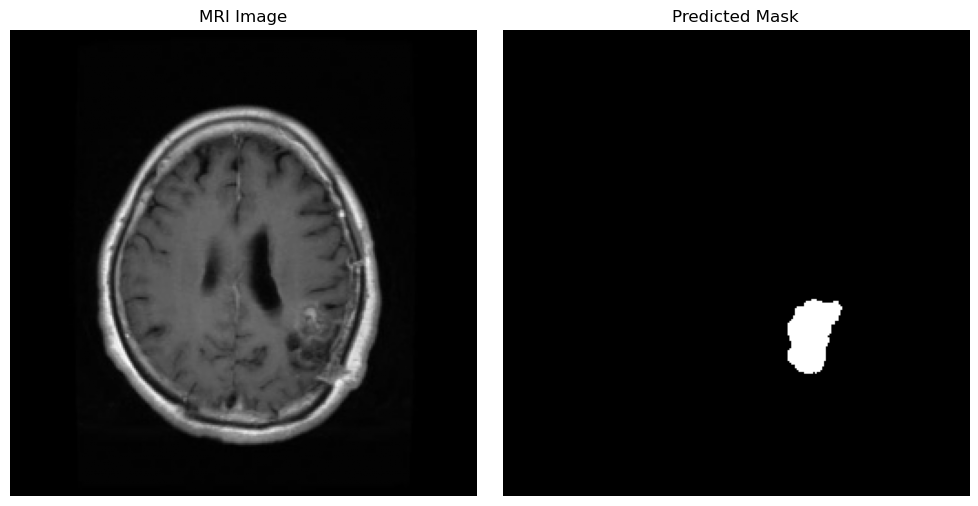

In [1]:
# ============================================================
# Predict & Visualize Mask for Any Single Image
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ---------------- Config ----------------
IMAGE_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\images\brisc2025_train_00027_gl_ax_t1.jpg"
MODEL_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras"

IMG_HEIGHT = 256
IMG_WIDTH = 256

# ---------------- Redefine custom loss/metric functions ----------------
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

bce = tf.keras.losses.BinaryCrossentropy()

def total_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

# ---------------- Load model ----------------
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "total_loss": total_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score,
        "dice_loss": dice_loss
    }
)

print(f"Loaded model from: {MODEL_PATH}")

# ---------------- Load & preprocess image ----------------
image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise ValueError(f"Could not read image: {IMAGE_PATH}")

image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))
image_norm = image.astype(np.float32) / 255.0
image_input = np.expand_dims(image_norm, axis=(0, -1))  # shape (1, H, W, 1)

# ---------------- Predict ----------------
pred = model.predict(image_input, verbose=0)
pred_mask = (pred[0, :, :, 0] > 0.5).astype(np.float32)

# ---------------- Plot ----------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_norm, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Model loaded successfully

Image:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\images\brisc2025_train_00007_gl_ax_t1.jpg

Ground Truth Mask:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\masks\brisc2025_train_00007_gl_ax_t1.png


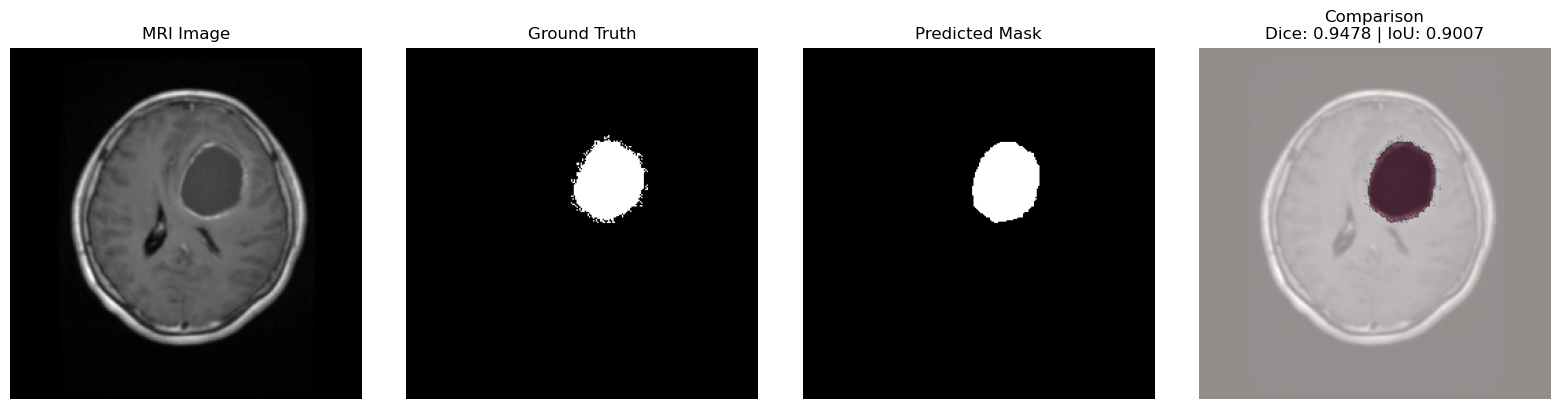


       SEGMENTATION RESULTS
Image          : brisc2025_train_00007_gl_ax_t1.jpg
Ground Truth   : brisc2025_train_00007_gl_ax_t1.png
------------------------------------------
Dice Score     : 0.9478
IoU Score      : 0.9007
------------------------------------------
Prediction threshold : 0.5


In [6]:
# ============================================================
# Predict + Ground Truth + Comparison for Any Single Image
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# ============================================================
# Config
# ============================================================


IMAGE_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\images\brisc2025_train_00007_gl_ax_t1.jpg"

MODEL_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras"

# Folder containing ground-truth masks
MASK_DIR = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\masks"

IMG_HEIGHT = 256
IMG_WIDTH = 256


# ============================================================
# Custom Loss / Metrics
# ============================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) +
        smooth
    )


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


bce = tf.keras.losses.BinaryCrossentropy()


def total_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)


def iou_score(y_true, y_pred, smooth=1e-6):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)

    union = (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) -
        intersection
    )

    return (intersection + smooth) / (union + smooth)


# ============================================================
# Load Model
# ============================================================

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "total_loss": total_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score,
        "dice_loss": dice_loss
    }
)

print("Model loaded successfully")


# ============================================================
# Find Ground Truth Mask Automatically
# ============================================================

# Example:
#
# Image:
# brisc2025_train_00027_gl_ax_t1.jpg
#
# Ground truth:
# brisc2025_train_00027_gl_ax_t1.png

image_name = os.path.splitext(
    os.path.basename(IMAGE_PATH)
)[0]

mask_path = os.path.join(
    MASK_DIR,
    image_name + ".png"
)

print("\nImage:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)

if not os.path.exists(mask_path):
    raise FileNotFoundError(
        f"Ground truth mask not found:\n{mask_path}"
    )


# ============================================================
# Load MRI Image
# ============================================================

image = cv2.imread(
    IMAGE_PATH,
    cv2.IMREAD_GRAYSCALE
)

if image is None:
    raise ValueError(
        f"Could not read image:\n{IMAGE_PATH}"
    )


# ============================================================
# Preprocess MRI
# ============================================================

# Gaussian denoising
image = cv2.GaussianBlur(
    image,
    (3, 3),
    0
)

# Resize
image = cv2.resize(
    image,
    (IMG_WIDTH, IMG_HEIGHT),
    interpolation=cv2.INTER_AREA
)

# Normalize to [0, 1]
image_norm = image.astype(
    np.float32
) / 255.0


# ============================================================
# Prepare Input for U-Net
# ============================================================

image_input = np.expand_dims(
    image_norm,
    axis=(0, -1)
)

# Shape:
# (1, 256, 256, 1)


# ============================================================
# Predict Segmentation Mask
# ============================================================

pred = model.predict(
    image_input,
    verbose=0
)

# Convert probability map to binary mask
pred_mask = (
    pred[0, :, :, 0] > 0.5
).astype(np.float32)


# ============================================================
# Load Ground Truth Mask
# ============================================================

gt_mask = cv2.imread(
    mask_path,
    cv2.IMREAD_GRAYSCALE
)

if gt_mask is None:
    raise ValueError(
        f"Could not read mask:\n{mask_path}"
    )


# ============================================================
# Preprocess Ground Truth Mask
# ============================================================

# IMPORTANT:
# Use nearest-neighbor interpolation for masks

gt_mask = cv2.resize(
    gt_mask,
    (IMG_WIDTH, IMG_HEIGHT),
    interpolation=cv2.INTER_NEAREST
)

# Convert mask to binary 0/1
gt_mask = (
    gt_mask > 0
).astype(np.float32)


# ============================================================
# Calculate Dice Score
# ============================================================

intersection = np.sum(
    gt_mask * pred_mask
)

dice = (
    2.0 * intersection
) / (
    np.sum(gt_mask) +
    np.sum(pred_mask) +
    1e-6
)


# ============================================================
# Calculate IoU Score
# ============================================================

union = (
    np.sum(gt_mask) +
    np.sum(pred_mask) -
    intersection
)

iou = (
    intersection + 1e-6
) / (
    union + 1e-6
)


# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(16, 4))


# ------------------------------------------------------------
# 1. MRI Image
# ------------------------------------------------------------

plt.subplot(1, 4, 1)

plt.imshow(
    image_norm,
    cmap="gray"
)

plt.title("MRI Image")
plt.axis("off")


# ------------------------------------------------------------
# 2. Ground Truth Mask
# ------------------------------------------------------------

plt.subplot(1, 4, 2)

plt.imshow(
    gt_mask,
    cmap="gray"
)

plt.title("Ground Truth")
plt.axis("off")


# ------------------------------------------------------------
# 3. Predicted Mask
# ------------------------------------------------------------

plt.subplot(1, 4, 3)

plt.imshow(
    pred_mask,
    cmap="gray"
)

plt.title("Predicted Mask")
plt.axis("off")


# ------------------------------------------------------------
# 4. Comparison / Overlay
# ------------------------------------------------------------

plt.subplot(1, 4, 4)

# MRI background
plt.imshow(
    image_norm,
    cmap="gray"
)

# Ground truth
plt.imshow(
    gt_mask,
    cmap="Blues",
    alpha=0.3
)

# Prediction
plt.imshow(
    pred_mask,
    cmap="Reds",
    alpha=0.4
)

plt.title(
    f"Comparison\n"
    f"Dice: {dice:.4f} | IoU: {iou:.4f}"
)

plt.axis("off")


plt.tight_layout()
plt.show()


# ============================================================
# Print Results
# ============================================================

print("\n==========================================")
print("       SEGMENTATION RESULTS")
print("==========================================")

print(f"Image          : {os.path.basename(IMAGE_PATH)}")
print(f"Ground Truth   : {os.path.basename(mask_path)}")

print("------------------------------------------")

print(f"Dice Score     : {dice:.4f}")
print(f"IoU Score      : {iou:.4f}")

print("------------------------------------------")
print("Prediction threshold : 0.5")
print("==========================================")

In [1]:
import os

IMAGE_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Segmentation\train\images\brisc2025_train_00171_gl_ax_t1.jpg"

# Get filename without extension
image_name = os.path.splitext(os.path.basename(IMAGE_PATH))[0]

print("Image name:")
print(image_name)

# Search entire segmented dataset for files containing this name
SEARCH_DIR = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented"

matches = []

for root, dirs, files in os.walk(SEARCH_DIR):
    for file in files:
        file_name = os.path.splitext(file)[0]

        if image_name in file_name:
            matches.append(os.path.join(root, file))

print("\nPossible matching files:")

for path in matches:
    print(path)

Image name:
brisc2025_train_00171_gl_ax_t1

Possible matching files:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\images\brisc2025_train_00171_gl_ax_t1.jpg
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\masks\brisc2025_train_00171_gl_ax_t1.png


Model loaded successfully

Image:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Segmentation\train\images\brisc2025_train_00171_gl_ax_t1.jpg

Ground Truth Mask:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\masks\brisc2025_train_00171_gl_ax_t1.png


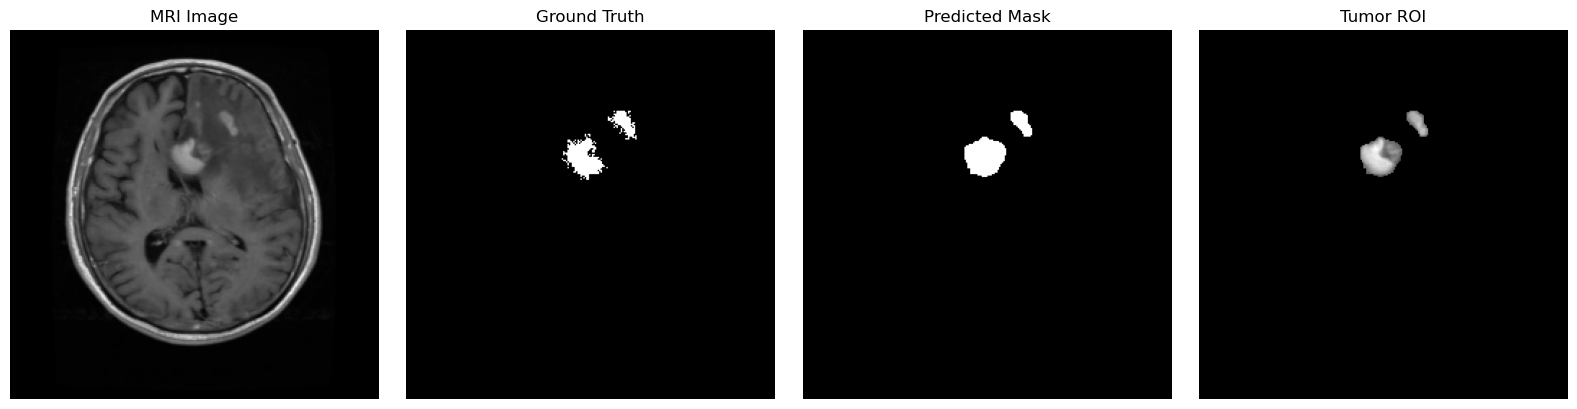


       SEGMENTATION RESULTS
Image          : brisc2025_train_00171_gl_ax_t1.jpg
Ground Truth   : brisc2025_train_00171_gl_ax_t1.png
------------------------------------------
Dice Score     : 0.8059
IoU Score      : 0.6749
------------------------------------------
Prediction threshold : 0.5


In [2]:
# ============================================================
# Predict + Ground Truth + ROI for Any Single Image
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os


# ============================================================
# Config
# ============================================================

# ONLY CHANGE THIS when testing another image

IMAGE_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Segmentation\train\images\brisc2025_train_00171_gl_ax_t1.jpg"

MODEL_PATH = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras"

# Folder containing ground-truth masks

MASK_DIR = r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Preprocessed_segmented\train\masks"

IMG_HEIGHT = 256
IMG_WIDTH = 256


# ============================================================
# Custom Loss / Metrics
# ============================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) +
        smooth
    )


def dice_loss(y_true, y_pred):

    return 1.0 - dice_coefficient(
        y_true,
        y_pred
    )


bce = tf.keras.losses.BinaryCrossentropy()


def total_loss(y_true, y_pred):

    return bce(
        y_true,
        y_pred
    ) + dice_loss(
        y_true,
        y_pred
    )


def iou_score(y_true, y_pred, smooth=1e-6):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    y_pred = tf.cast(
        y_pred > 0.5,
        tf.float32
    )

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    union = (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) -
        intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )


# ============================================================
# Load Model
# ============================================================

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "total_loss": total_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score,
        "dice_loss": dice_loss
    }
)

print("Model loaded successfully")


# ============================================================
# Find Ground Truth Mask Automatically
# ============================================================

# Image:
# brisc2025_train_00007_gl_ax_t1.jpg
#
# Ground Truth:
# brisc2025_train_00007_gl_ax_t1.png

image_name = os.path.splitext(
    os.path.basename(IMAGE_PATH)
)[0]


mask_path = os.path.join(
    MASK_DIR,
    image_name + ".png"
)


print("\nImage:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)


if not os.path.exists(mask_path):

    raise FileNotFoundError(
        f"Ground truth mask not found:\n{mask_path}"
    )


# ============================================================
# Load MRI Image
# ============================================================

image = cv2.imread(
    IMAGE_PATH,
    cv2.IMREAD_GRAYSCALE
)


if image is None:

    raise ValueError(
        f"Could not read image:\n{IMAGE_PATH}"
    )


# ============================================================
# Preprocess MRI
# ============================================================

# Gaussian denoising

image = cv2.GaussianBlur(
    image,
    (3, 3),
    0
)


# Resize

image = cv2.resize(
    image,
    (IMG_WIDTH, IMG_HEIGHT),
    interpolation=cv2.INTER_AREA
)


# Normalize to [0, 1]

image_norm = image.astype(
    np.float32
) / 255.0


# ============================================================
# Prepare Input for U-Net
# ============================================================

image_input = np.expand_dims(
    image_norm,
    axis=(0, -1)
)

# Shape:
# (1, 256, 256, 1)


# ============================================================
# Predict Segmentation Mask
# ============================================================

pred = model.predict(
    image_input,
    verbose=0
)


# Convert probability map to binary mask

pred_mask = (
    pred[0, :, :, 0] > 0.5
).astype(np.float32)


# ============================================================
# Create Tumor ROI
# ============================================================

# Keep only the pixels predicted as tumor

roi = image_norm * pred_mask


# ============================================================
# Load Ground Truth Mask
# ============================================================

gt_mask = cv2.imread(
    mask_path,
    cv2.IMREAD_GRAYSCALE
)


if gt_mask is None:

    raise ValueError(
        f"Could not read mask:\n{mask_path}"
    )


# ============================================================
# Preprocess Ground Truth Mask
# ============================================================

# Resize using nearest-neighbor

gt_mask = cv2.resize(
    gt_mask,
    (IMG_WIDTH, IMG_HEIGHT),
    interpolation=cv2.INTER_NEAREST
)


# Convert to binary 0/1

gt_mask = (
    gt_mask > 0
).astype(np.float32)


# ============================================================
# Calculate Dice Score
# ============================================================

intersection = np.sum(
    gt_mask * pred_mask
)


dice = (
    2.0 * intersection
) / (
    np.sum(gt_mask) +
    np.sum(pred_mask) +
    1e-6
)


# ============================================================
# Calculate IoU Score
# ============================================================

union = (
    np.sum(gt_mask) +
    np.sum(pred_mask) -
    intersection
)


iou = (
    intersection + 1e-6
) / (
    union + 1e-6
)


# ============================================================
# Visualization
# ============================================================

plt.figure(figsize=(16, 4))


# ------------------------------------------------------------
# 1. MRI Image
# ------------------------------------------------------------

plt.subplot(1, 4, 1)

plt.imshow(
    image_norm,
    cmap="gray"
)

plt.title("MRI Image")

plt.axis("off")


# ------------------------------------------------------------
# 2. Ground Truth Mask
# ------------------------------------------------------------

plt.subplot(1, 4, 2)

plt.imshow(
    gt_mask,
    cmap="gray"
)

plt.title("Ground Truth")

plt.axis("off")


# ------------------------------------------------------------
# 3. Predicted Mask
# ------------------------------------------------------------

plt.subplot(1, 4, 3)

plt.imshow(
    pred_mask,
    cmap="gray"
)

plt.title("Predicted Mask")

plt.axis("off")


# ------------------------------------------------------------
# 4. Tumor ROI
# ------------------------------------------------------------

plt.subplot(1, 4, 4)

plt.imshow(
    roi,
    cmap="gray"
)

plt.title("Tumor ROI")

plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# Print Results
# ============================================================

print("\n==========================================")
print("       SEGMENTATION RESULTS")
print("==========================================")

print(
    f"Image          : "
    f"{os.path.basename(IMAGE_PATH)}"
)

print(
    f"Ground Truth   : "
    f"{os.path.basename(mask_path)}"
)

print("------------------------------------------")

print(
    f"Dice Score     : {dice:.4f}"
)

print(
    f"IoU Score      : {iou:.4f}"
)

print("------------------------------------------")

print(
    "Prediction threshold : 0.5"
)

print("==========================================")